# ##########################################################################
# LABORATORIO NO. 2: ETL Y PREDICCIÓN DE CONVERSIÓN SAAS.
# * Luis Hernando Montoya Muñoz
# * Santiago Cortes Murcia
# * Gustavo Adolfo Morales Ortiz
# * Daniel Fernando Montenegro Gómez
# ##########################################################################

PASOS PARA LA CONFIGURACIÓN DEL NOTEBOOKK

# En Windows
python -m venv .venv

# En macOS/Linux
python3 -m venv .venv

3. Activar el entorno virtual

# En Windows (PowerShell)
.\.venv\Scripts\Activate.ps1

# En Windows (CMD)
.\.venv\Scripts\activate

# En macOS/Linux
source .venv/bin/activate

# ==========================================
# 1. CONFIGURACIÓN DEL ENTORNO
# ==========================================

In [1]:
# 1. Instalación de librerías necesarias (en caso de no estar presentes)
!pip install pandas numpy matplotlib seaborn scikit-learn

# 2. Carga de librerías base
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Configuración estética para los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías instaladas y cargadas correctamente.")



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Librerías instaladas y cargadas correctamente.


# ###########################################################################
# 3. Metodología de Ejecución: Extracción y Perfilamiento

# ### 3.1. Fuentes de Datos Identificadas
# ###########################################################################

In [3]:
# Configuración para visualizar todas las columnas en el notebook
pd.set_option('display.max_columns', None)

# 1. Configuración de rutas (Rutas relativas para que sea reproducible)
data_raw_path = "../data/raw/"
file_users = os.path.join(data_raw_path, "lab2_trial_conversion_users.csv")
file_dict = os.path.join(data_raw_path, "lab2_data_dictionary.csv")

# 2. Extracción de los datos [cite: 34]
try:
    df_users = pd.read_csv(file_users)
    df_dict = pd.read_csv(file_dict)
    print("✅ Extracción exitosa.")
except FileNotFoundError as e:
    print(f"❌ Error: No se encontraron los archivos en la ruta especificada. {e}")

✅ Extracción exitosa.


# ###########################################################################
### 3.2. Validación de Integridad de Registros
# ###########################################################################

In [4]:
# 5. Identificación de Duplicados e Integridad de Usuarios
print("\n--- DIAGNÓSTICO DE DUPLICADOS ---")

# Conteo de duplicados exactos (toda la fila igual)
total_duplicados = df_users.duplicated().sum() # Debería ser 45 según el caso [cite: 22]

# Conteo de usuarios únicos vs registros totales
total_registros = len(df_users) # 2545 [cite: 21]
usuarios_unicos = df_users['user_id'].nunique() # 2500 [cite: 21]

print(f"Total de registros en el dataset: {total_registros}")
print(f"Registros duplicados detectados: {total_duplicados}")
print(f"Usuarios únicos (user_id): {usuarios_unicos}")

# Validación de consistencia: (Total - Duplicados = Únicos)
if (total_registros - total_duplicados) == usuarios_unicos:
    print("✅ La integridad de los datos es consistente con el requerimiento del laboratorio.")
else:
    print("⚠️ Atención: Existe una discrepancia entre duplicados y usuarios únicos.")



# Buscamos los user_id que aparecen más de una vez
ids_duplicados = df_users[df_users.duplicated('user_id', keep=False)].sort_values('user_id')

print(f'\nFilas con IDs repetidos: {len(ids_duplicados)}')
display(ids_duplicados.head(10))



--- DIAGNÓSTICO DE DUPLICADOS ---
Total de registros en el dataset: 2545
Registros duplicados detectados: 18
Usuarios únicos (user_id): 2500
⚠️ Atención: Existe una discrepancia entre duplicados y usuarios únicos.

Filas con IDs repetidos: 90


,user_id,signup_date,trial_end_date,trial_length_days,age,country,gender,device_type,acquisition_channel,city_tier,preferred_plan_before_conversion,days_active_trial,sessions_count,avg_session_minutes,features_used,support_tickets,emails_opened,webinar_attended,payment_method_on_file,referred_friend,discount_offered_pct,plan_page_views,last_activity_gap_days,satisfaction_score,monthly_income_usd,converted_to_paid_plan,selected_plan
52,USR-00053,2025-01-28,2025-02-18,21,39.0,México,female,mobile,partner,tier_2,basic,18,30,21.5,6,0,6,0,0,0,5,6,12,NaN,$1430,0,none
2520,USR-00053,2025-01-28,2025-02-18,21,39.0,México,female,mobile,partner,tier_2,basic,18,30,21.5,6,0,6,0,0,0,5,6,12,NaN,1430.0,0,none
69,USR-00070,2025-10-21,2025-11-04,14,31.0,México,male,desktop,partner,tier_1,standard,4,13,3.0,9,0,4,0,1,0,5,3,16,5.7,1746.0,0,none
2540,USR-00070,2025-10-21,2025-11-04,14,31.0,México,male,desktop,partner,tier_1,standard,4,13,3.0,9,0,4,0,1,0,5,3,16,5.7,1746.0,0,none
142,USR-00143,2025-08-05,2025-08-26,21,35.0,Colombia,female,mobile,organic search,tier_2,basic,13,26,20.7,12,0,9,0,0,0,10%,2,16,10.0,975.0,0,none
2517,USR-00143,2025-08-05,2025-08-26,21,35.0,Colombia,female,mobile,organic search,tier_2,basic,13,26,20.7,12,0,9,0,0,0,10,2,16,10.0,975.0,0,none
219,USR-00220,2025-12-11,2026-01-01,21,24.0,MÉXICO,male,desktop,organic_search,tier_1,basic,10,23,14.7,18,1,6,0,0,0,0,5,14,8.9,1545.0,1,standard
2503,USR-00220,2025-12-11,2026-01-01,21,24.0,México,male,desktop,organic search,tier_1,basic,10,23,14.7,18,1,6,0,0,0,0,5,14,8.9,1545.0,1,standard
314,USR-00315,2025-09-28,2025-10-12,14,37.0,Chile,male,mobile,partner,tier_1,basic,10,18,18.7,11,0,6,1,0,0,5,4,9,6.2,1597.0,0,none
2501,USR-00315,2025-09-28,2025-10-12,14,37.0,chile,male,mobile,Partner,tier_1,basic,10,18,18.7,11,0,6,1,0,0,5,4,9,6.2,1597.0,0,none


# ###########################################################################
# 2. Sección de ETL (Limpieza)
# ###########################################################################

In [6]:
# 1. Resumen de tipos y nulos
from IPython.core.display_functions import display
print("--- INFO GENERAL ---")
resumen = pd.DataFrame({
    "Tipo": df_users.dtypes,
    "Nulos": df_users.isnull().sum(),
    "% Nulos": (df_users.isnull().sum() / len(df_users)) * 100,
    "No nulos": df_users.notnull().sum()
})
display(resumen)

# 2. Conteo de nulos detallado
print("\n--- Valores Nulos ---")
nulos = df_users.isnull().sum()
display(nulos[nulos > 0])

# 3. Estadísticos descriptivos para detectar outliers
print("\n--- Estadísticos descriptivos ---")
display(df_users.describe())

# 4. Tasa de conversión
print("\n--- BALANCE DE CLASE OBJETIVO ---")
display(df_users['converted_to_paid_plan'].value_counts(normalize=True))




--- INFO GENERAL ---


,Tipo,Nulos,% Nulos,No nulos
user_id,str,0,0.000000,2545
signup_date,str,0,0.000000,2545
trial_end_date,str,0,0.000000,2545
trial_length_days,int64,0,0.000000,2545
age,float64,76,2.986248,2469
country,str,39,1.532417,2506
gender,str,0,0.000000,2545
device_type,str,41,1.611002,2504
acquisition_channel,str,0,0.000000,2545
city_tier,str,0,0.000000,2545



--- Valores Nulos ---


age                     76
country                 39
device_type             41
avg_session_minutes    102
satisfaction_score     152
monthly_income_usd     119
dtype: int64


--- Estadísticos descriptivos ---


,trial_length_days,age,days_active_trial,sessions_count,avg_session_minutes,features_used,support_tickets,emails_opened,webinar_attended,payment_method_on_file,referred_friend,plan_page_views,last_activity_gap_days,satisfaction_score,converted_to_paid_plan
count,2545.000000,2469.000000,2545.000000,2545.000000,2443.000000,2545.000000,2545.000000,2545.000000,2545.000000,2545.000000,2545.000000,2545.000000,2545.000000,2393.000000,2545.000000
mean,15.401572,32.784123,9.036149,17.146169,15.075849,10.082122,0.710020,5.574853,0.211002,0.453831,0.176817,3.460904,10.367387,7.130338,0.235756
std,6.564676,8.660253,5.343642,17.108395,12.383985,3.677113,0.836471,2.467715,0.408100,0.497962,0.381589,2.076974,6.265343,1.695488,0.424554
min,7.000000,18.000000,1.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,14.000000,26.000000,5.000000,8.000000,10.200000,8.000000,0.000000,4.000000,0.000000,0.000000,0.000000,2.000000,6.000000,5.900000,0.000000
50%,14.000000,33.000000,8.000000,15.000000,14.100000,10.000000,1.000000,5.000000,0.000000,0.000000,0.000000,3.000000,10.000000,7.100000,0.000000
75%,21.000000,39.000000,12.000000,22.000000,18.400000,12.000000,1.000000,7.000000,0.000000,1.000000,0.000000,5.000000,14.000000,8.400000,0.000000
max,30.000000,64.000000,30.000000,273.000000,179.700000,28.000000,5.000000,16.000000,1.000000,1.000000,1.000000,15.000000,37.000000,10.000000,1.000000



--- BALANCE DE CLASE OBJETIVO ---


converted_to_paid_plan
0    0.764244
1    0.235756
Name: proportion, dtype: float64

# Inconsistencias categóricas (variantes de escritura, espacios o mayúsculas)

In [12]:
# Ejemplo para la columna 'country' o 'device_type'
valores_unicos = df_users['country'].unique()
print(valores_unicos)

# Ejemplo para la columna 'country' o 'device_type'
valores_unicos = df_users['device_type'].unique()
print(f'\n{valores_unicos}')

# Ejemplo para la columna 'countary' o 'device_type'
valores_unicos = df_users['gender'].unique()
print(f'\n{valores_unicos}\n')

<StringArray>
[      'peru',     'México', ' COLOMBIA ',   'Colombia',          nan,
      'Chile',       'Perú',    ' MÉXICO',    'Ecuador',  'Argentina',
     ' PERÚ ',   'colombia',     'mexico', 'Argentina ',  'argentina',
      'chile',    'ecuador']
Length: 17, dtype: str

<StringArray>
[  'Mobile',   'mobile',  'desktop',   'tablet',  'DESKTOP',  'Desktop',
        nan,   'Tablet', ' mobile ']
Length: 9, dtype: str

<StringArray>
['male', 'female', 'prefer_not_to_say', 'non_binary']
Length: 4, dtype: str



# ###########################################################################
# 4. TRANSFORMACIÓN (LIMPIEZA Y NORMALIZACIÓN)
* Eliminación de duplicados y registros inconsistentes.
* Imputación de valores nulos (Moda para categorías, Mediana para numéricos).
* Unificación de categorías (Países y Dispositivos).
# ###########################################################################

In [ ]:
# Clonamos el dataframe original para preservar la fuente (Inmutabilidad)
df_cleaned = df_users.copy()

# 1. Eliminación de duplicados (Exactos + Por ID)
df_cleaned = df_cleaned.drop_duplicates() # Elimina los 18 exactos
df_cleaned = df_cleaned.drop_duplicates(subset=['user_id'], keep='first') # Elimina los 27 por ID

print(f"✅ Cantidad de registros producto de la depuración de duplicados: {len(df_cleaned)} (Objetivo: 2500)")

✅ Registros tras limpieza de duplicados: 2500 (Objetivo: 2500)


In [9]:
import numpy as np

def clean_numeric_strings(value):
    # Verificamos si es nulo (pd.NA, np.nan o None)
    if pd.isna(value):
        return np.nan
    
    if isinstance(value, str):
        # Limpieza de símbolos
        clean_val = value.replace('$', '').replace('%', '').replace(',', '').strip()
        
        # Verificamos si después de limpiar quedó algo (evita errores con strings vacíos)
        if clean_val == '' or clean_val.lower() == 'nan':
            return np.nan
            
        try:
            return float(clean_val)
        except ValueError:
            return np.nan # Si hay algo que aún no es número, devolvemos NaN para no romper el código
            
    return value

# Aplicación y Casting
df_cleaned['monthly_income_usd'] = df_cleaned['monthly_income_usd'].apply(clean_numeric_strings)
df_cleaned['discount_offered_pct'] = df_cleaned['discount_offered_pct'].apply(clean_numeric_strings)

print("✅ Conversión exitosa. Tipos finales:")
print(df_cleaned[['monthly_income_usd', 'discount_offered_pct']].dtypes)

✅ Conversión exitosa. Tipos finales:
monthly_income_usd      float64
discount_offered_pct    float64
dtype: object


In [10]:
# Imputación de variables numéricas con la mediana
num_cols_nan = ['age', 'avg_session_minutes', 'satisfaction_score', 'monthly_income_usd']
for col in num_cols_nan:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Imputación de variables categóricas con la moda
cat_cols_nan = ['device_type', 'country']
for col in cat_cols_nan:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print(f"✅ Nulos restantes en el dataset: {df_cleaned.isnull().sum().sum()}")

✅ Nulos restantes en el dataset: 0


In [2]:
# Convertir a minúsculas y quitar espacios en blanco en todas las columnas de texto
object_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in object_cols:
    df_cleaned[col] = df_cleaned[col].str.lower().str.strip()

NameError: name 'df_cleaned' is not defined

In [118]:
# 1. Normalización final de texto 
for col in ['country', 'device_type']:
    # Aseguramos minúsculas y quitamos espacios
    df_cleaned[col] = df_cleaned[col].astype(str).str.lower().str.strip()
    # Quitamos tildes para unificar (Perú -> peru, México -> mexico)
    df_cleaned[col] = df_cleaned[col].str.replace('á', 'a').str.replace('é', 'e')\
                                     .str.replace('í', 'i').str.replace('ó', 'o')\
                                     .str.replace('ú', 'u')

# 2. Imputación de nulos con la Moda
for col in ['country', 'device_type']:
    # Calculamos la moda (el valor [0] es el más frecuente)
    valor_moda = df_cleaned[col].mode()[0]
    df_cleaned[col] = df_cleaned[col].replace('nan', valor_moda).fillna(valor_moda)

print(f"✅ VALIDACIÓN FINAL ANTES DE GUARDAR:\n")
print(f"- Países: {df_cleaned['country'].unique()}\n")
print(f"- Dispositivos: {df_cleaned['device_type'].unique()}")

# 3. GUARDAR EN PROCESSED (Ahora sí, datos perfectos)
df_cleaned.to_csv(path_final, index=False)

✅ VALIDACIÓN FINAL ANTES DE GUARDAR:

- Países: <StringArray>
['peru', 'mexico', 'colombia', 'chile', 'ecuador', 'argentina']
Length: 6, dtype: str

- Dispositivos: <StringArray>
['mobile', 'desktop', 'tablet']
Length: 3, dtype: str


In [119]:
cols_a_imputar = ['age', 'avg_session_minutes', 'satisfaction_score', 'monthly_income_usd']

# 2. Aplicamos la imputación por MEDIANA
for col in cols_a_imputar:
    mediana = df_cleaned[col].median()
    df_cleaned[col] = df_cleaned[col].fillna(mediana)
    print(f"✅ Columna '{col}': Imputada con mediana = {mediana}")

# 3. Verificación final de nulos
print("\n--- ESTADO FINAL DE NULOS ---")
print(df_cleaned[cols_a_imputar].isnull().sum())

display(df_cleaned.describe())

✅ Columna 'age': Imputada con mediana = 33.0
✅ Columna 'avg_session_minutes': Imputada con mediana = 14.1
✅ Columna 'satisfaction_score': Imputada con mediana = 7.1
✅ Columna 'monthly_income_usd': Imputada con mediana = 1458.0

--- ESTADO FINAL DE NULOS ---
age                    0
avg_session_minutes    0
satisfaction_score     0
monthly_income_usd     0
dtype: int64


,trial_length_days,age,days_active_trial,sessions_count,avg_session_minutes,features_used,support_tickets,emails_opened,webinar_attended,payment_method_on_file,referred_friend,discount_offered_pct,plan_page_views,last_activity_gap_days,satisfaction_score,monthly_income_usd,converted_to_paid_plan
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000
mean,15.391200,32.814800,9.029600,17.090400,14.98956,10.079600,0.70960,5.573200,0.211600,0.452400,0.177600,8.684000,3.467200,10.361600,7.11932,1463.076000,0.234000
std,6.553483,8.518822,5.346864,16.915646,11.90587,3.672528,0.83615,2.469308,0.408524,0.497829,0.382252,8.224062,2.079292,6.259147,1.64287,670.072816,0.423457
min,7.000000,18.000000,1.000000,1.000000,2.00000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,250.000000,0.000000
25%,14.000000,27.000000,5.000000,8.000000,10.40000,8.000000,0.00000,4.000000,0.000000,0.000000,0.000000,0.000000,2.000000,6.000000,6.00000,992.750000,0.000000
50%,14.000000,33.000000,8.000000,14.000000,14.10000,10.000000,1.00000,5.000000,0.000000,0.000000,0.000000,10.000000,3.000000,10.000000,7.10000,1458.000000,0.000000
75%,21.000000,39.000000,12.000000,22.000000,18.20000,12.000000,1.00000,7.000000,0.000000,1.000000,0.000000,15.000000,5.000000,14.000000,8.30000,1914.500000,0.000000
max,30.000000,64.000000,30.000000,273.000000,179.70000,28.000000,5.00000,16.000000,1.000000,1.000000,1.000000,25.000000,15.000000,37.000000,10.00000,4585.000000,1.000000


# ACTUALIZAR RUTA EL NUEVO ARCHIVO PROCESADO.

In [120]:
import os

# 1. Definimos la ruta absoluta proporcionada
ruta_procesados = r'C:\Users\slaye\Documents\UAO\ETL\Lab 2\data\processed'
nombre_archivo = 'lab2_trial_conversion_cleaned.csv'
path_final = os.path.join(ruta_procesados, nombre_archivo)

# 2. Guardar el DataFrame limpio
# index=False evita que se cree una columna extra de 'Unnamed: 0' al volver a leerlo
df_cleaned.to_csv(path_final, index=False)

# 3. Verificación de integridad del archivo guardado
if os.path.exists(path_final):
    print(f"✅ Archivo guardado y verificado en:\n📍 {path_final}")
    print(f"📊 Registros exportados: {len(df_cleaned)}")
else:
    print("❌ Error: No se pudo confirmar el guardado del archivo.")

✅ Archivo guardado y verificado en:
📍 C:\Users\slaye\Documents\UAO\ETL\Lab 2\data\processed\lab2_trial_conversion_cleaned.csv
📊 Registros exportados: 2500


## 5. Análisis Exploratorio de Datos (EDA)
### 5.1. Segmentación por País y Tipo de Dispositivo

C:\Users\slaye\AppData\Local\Temp\ipykernel_18824\3483110026.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='converted_to_paid_plan', data=df_cleaned, ax=axes[0], palette='viridis')
C:\Users\slaye\AppData\Local\Temp\ipykernel_18824\3483110026.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='device_type', y='converted_to_paid_plan', data=df_cleaned, ax=axes[1], palette='magma')


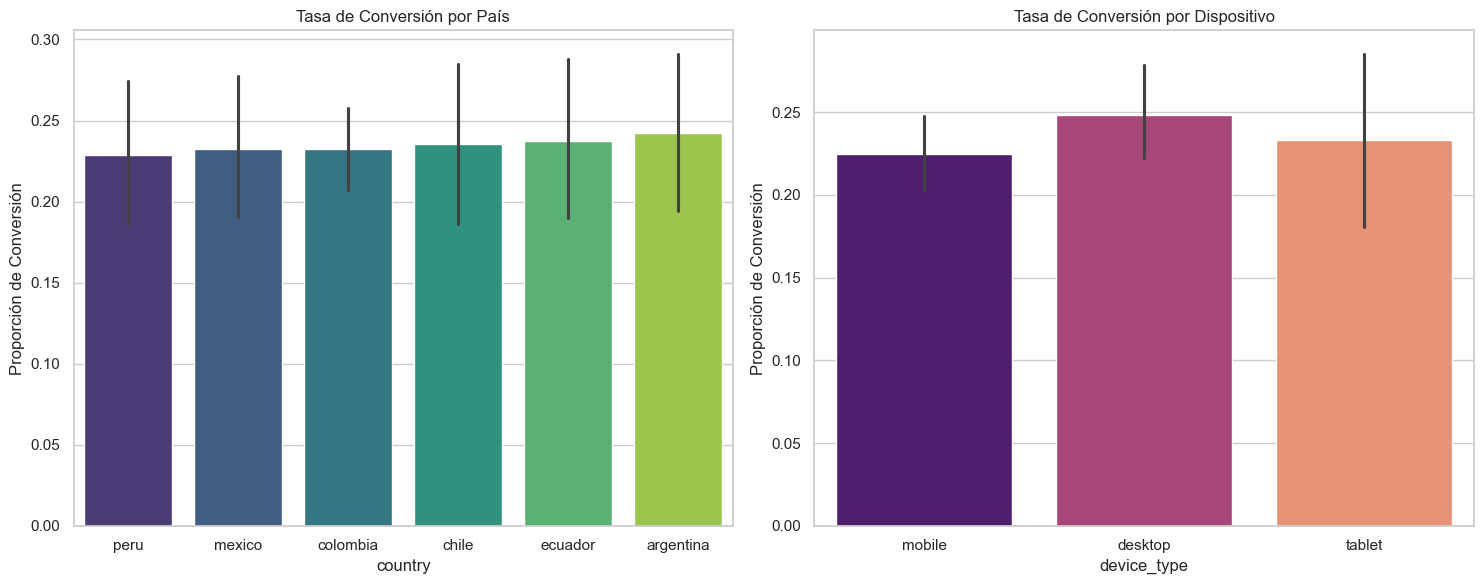

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Conversión por País
sns.barplot(x='country', y='converted_to_paid_plan', data=df_cleaned, ax=axes[0], palette='viridis')
axes[0].set_title('Tasa de Conversión por País')
axes[0].set_ylabel('Proporción de Conversión')

# 2. Conversión por Dispositivo
sns.barplot(x='device_type', y='converted_to_paid_plan', data=df_cleaned, ax=axes[1], palette='magma')
axes[1].set_title('Tasa de Conversión por Dispositivo')
axes[1].set_ylabel('Proporción de Conversión')

plt.tight_layout()
plt.show()

# ############################################################################
### 5.2. Análisis de Correlación de Pearson
# ############################################################################

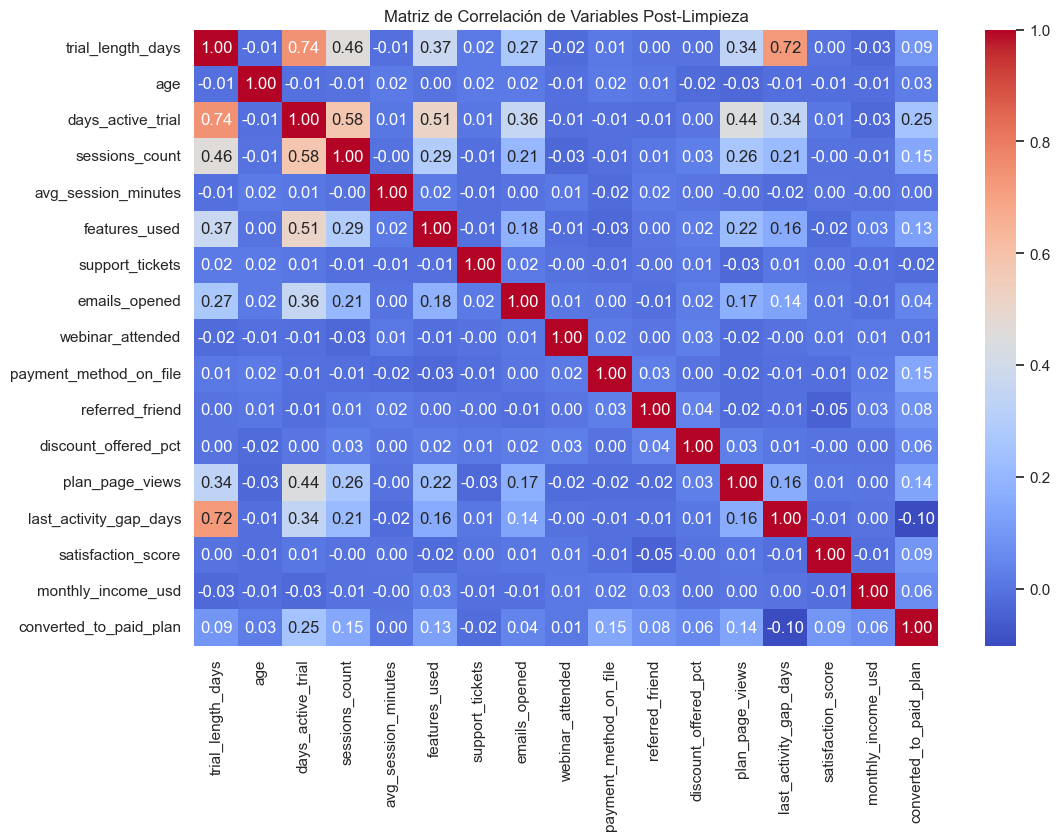

--- Correlación con la Conversión ---
converted_to_paid_plan    1.000000
days_active_trial         0.248965
sessions_count            0.150841
payment_method_on_file    0.146819
plan_page_views           0.137109
features_used             0.125937
satisfaction_score        0.093469
trial_length_days         0.092883
referred_friend           0.081838
monthly_income_usd        0.064594
discount_offered_pct      0.057436
emails_opened             0.043886
age                       0.025884
webinar_attended          0.014374
avg_session_minutes       0.004723
support_tickets          -0.019344
last_activity_gap_days   -0.101386
Name: converted_to_paid_plan, dtype: float64


In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selección variables numéricas para la correlación
cols_numericas = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df_cleaned[cols_numericas].corr()

# 2. Visualización con Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matriz de Correlación de Variables Post-Limpieza')
plt.show()

# 3. Ver específicamente la correlación con la variable OBJETIVO
print("--- Correlación con la Conversión ---")
print(corr_matrix['converted_to_paid_plan'].sort_values(ascending=False))

# ############################################################################
# 6. Codificación de variables categóricas               
# ############################################################################

In [123]:
import pandas as pd
import os

# 1. Definir y verificar la fuente de datos (Processed)
ruta_archivo = r'C:\Users\slaye\Documents\UAO\ETL\Lab 2\data\processed\lab2_trial_conversion_cleaned.csv'

if os.path.exists(ruta_archivo):
    # Cargar el dataset que ya pasó por limpieza y normalización
    df_modelo = pd.read_csv(ruta_archivo)
    print(f"📂 ARCHIVO ORIGEN: {os.path.basename(ruta_archivo)}")
    print(f"✅ Estado del dato: Limpio, Normalizado e Imputado.")
else:
    print("❌ ERROR: No se encontró el archivo en 'processed'. Verifica la fase anterior.")

# 2. Definir columnas fuente para One-Hot Encoding
# Estas vienen de tu normalización previa (peru, mexico, mobile, desktop, etc.)
cols_categoricas = ['country', 'device_type', 'gender', 'acquisition_channel']

print(f"\n--- Aplicando One-Hot Encoding ---")
print(f"Fuentes originales: {cols_categoricas}")

# 3. Ejecutar la transformación
# drop_first=True es vital para evitar la multicolinealidad en Regresión Logística
df_final = pd.get_dummies(df_modelo, columns=cols_categoricas, drop_first=True)

# 4. Imprimir resultado de la transformación
nuevas_cols = [c for c in df_final.columns if any(cat in c for cat in cols_categoricas)]
print(f"\n🚀 RESULTADO:")
print(f"Se generaron {len(nuevas_cols)} nuevas columnas binarias.")
print(f"Ejemplos de nuevas variables: {nuevas_cols[:5]}")
print(f"Dimensiones finales del dataset: {df_final.shape}")

📂 ARCHIVO ORIGEN: lab2_trial_conversion_cleaned.csv
✅ Estado del dato: Limpio, Normalizado e Imputado.

--- Aplicando One-Hot Encoding ---
Fuentes originales: ['country', 'device_type', 'gender', 'acquisition_channel']

🚀 RESULTADO:
Se generaron 25 nuevas columnas binarias.
Ejemplos de nuevas variables: ['country_chile', 'country_colombia', 'country_ecuador', 'country_mexico', 'country_peru']
Dimensiones finales del dataset: (2500, 48)


In [124]:
# 1. Definir la variable objetivo (Target)
y = df_final['converted_to_paid_plan']

# 2. Definir las variables predictoras (Features)
# Excluimos las columnas que no son numéricas o son IDs/Fechas
cols_a_excluir = [
    'user_id', 'signup_date', 'trial_end_date', 'converted_to_paid_plan', 
    'selected_plan', 'preferred_plan_before_conversion'
]

X = df_final.drop(columns=cols_a_excluir)

print(f"✅ Variables de entrenamiento (X) listas: {X.shape[1]} predictores.")
print(f"✅ Variable objetivo (y) lista: {y.shape[0]} etiquetas.\n")

# Verificamos que no queden tipos 'object'
print(f"Tipos de datos en X:\n{X.dtypes.value_counts()}")



# 1. Identificar TODAS las columnas que aún son texto (object o string)
cols_categoricas_restantes = X.select_dtypes(include=['object', 'string']).columns
print(f"\n⚠️ Columnas de texto detectadas en X: {list(cols_categoricas_restantes)}")

# 2. Aplicar One-Hot Encoding a lo que falte
# Si ya lo habías hecho antes, este paso asegura que X sea 100% numérico
X_final = pd.get_dummies(X, columns=cols_categoricas_restantes, drop_first=True)

# 3. Re-intentar la Partición y el Escalamiento
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ ¡Éxito! X ahora tiene {X_train_scaled.shape[1]} columnas numéricas.")
print(f"✅ Escalamiento completado sin errores.")

✅ Variables de entrenamiento (X) listas: 42 predictores.
✅ Variable objetivo (y) lista: 2500 etiquetas.

Tipos de datos en X:
bool       25
int64      11
float64     5
str         1
Name: count, dtype: int64

⚠️ Columnas de texto detectadas en X: ['city_tier']
✅ ¡Éxito! X ahora tiene 43 columnas numéricas.
✅ Escalamiento completado sin errores.


# ############################################################################
# 7.	Entrenamiento del modelo y escalamiento de características
# ############################################################################

In [125]:
# Entrenar el modelo
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Calcular el Accuracy (Exactitud)
score = model.score(X_test_scaled, y_test)
print(f"🎯 Precisión del modelo (Accuracy): {score:.4f}")

🎯 Precisión del modelo (Accuracy): 0.7860


# ############################################################################
# 8. La Matriz de Confusión
# ############################################################################

<Figure size 800x600 with 0 Axes>

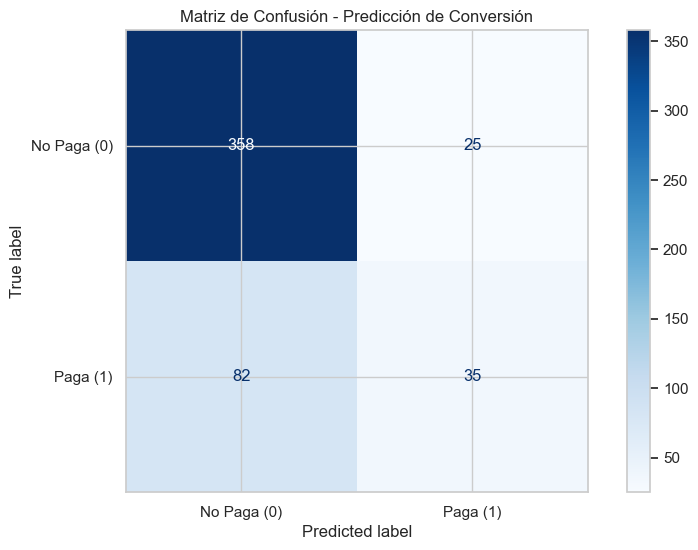

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       383
           1       0.58      0.30      0.40       117

    accuracy                           0.79       500
   macro avg       0.70      0.62      0.63       500
weighted avg       0.76      0.79      0.76       500



In [126]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Entrenar el modelo de Regresión Logística
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 2. Realizar predicciones sobre el set de prueba (el 20% que el modelo no conoce)
y_pred = model.predict(X_test_scaled)

# 3. Generar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

# 4. Visualización Profesional
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Paga (0)', 'Paga (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Predicción de Conversión')
plt.show()

# 5. Reporte de Métricas
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))